## **Q4.  Model Development & Comparative Study**

In [35]:
df_final = df_fe[final_features + ["class"]]
X = df_final.drop("class", axis=1)
y = df_final["class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(416, 14) (104, 14)


###**Q4.a. Train at least 3 models:**
• Logistic Regression  
• Decision Tree  
• One advanced model (Random Forest)

####**Logistic Regression**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Training
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Accuracy: 0.9134615384615384

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.93      0.94      0.94        71

    accuracy                           0.91       104
   macro avg       0.90      0.90      0.90       104
weighted avg       0.91      0.91      0.91       104

ROC-AUC: 0.9684165599658557


####**Decision Tree**

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Training
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]))


Accuracy: 0.9807692307692307

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       1.00      0.97      0.99        71

    accuracy                           0.98       104
   macro avg       0.97      0.99      0.98       104
weighted avg       0.98      0.98      0.98       104

ROC-AUC: 0.9859154929577465


####**Random Forest**

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Training
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy: 0.9903846153846154

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       1.00      0.99      0.99        71

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104

ROC-AUC: 1.0


###**Q4.b.Perform:**
• Hyperparameter tuning  
• Cross-validation  

In [86]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# Best model
best_rf = grid.best_estimator_

# Evaluate
y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))



Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 0.9807692307692307

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       1.00      0.97      0.99        71

    accuracy                           0.98       104
   macro avg       0.97      0.99      0.98       104
weighted avg       0.98      0.98      0.98       104

ROC-AUC: 1.0


In [88]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)
results = results.sort_values(by="mean_test_score", ascending=False)

results[["params", "mean_test_score", "std_test_score"]].head()

,params,mean_test_score,std_test_score
12,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.966380,0.013934
0,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.963970,0.015151
1,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.963970,0.015151
13,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.963970,0.015151
2,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.963941,0.017040


Grid Search systematically evaluates multiple combinations of hyperparameters to identify the optimal model configuration. In this analysis, different values of n_estimators, max_depth, and min_samples_split were tested using 5-fold cross-validation. Each combination was evaluated based on mean accuracy across folds to ensure reliable performance. The best parameters were selected based on the highest validation score. This approach helps improve model performance while reducing the risk of overfitting.

###**Q4.c. Performance Comparison of Models**

| **Model**       | **Accuracy** | **Precision** | **Recall** | **F1-Score** | **ROC-AUC** |
| ------------------- | -------- | --------- | ------ | -------- | ------- |
| ***Logistic Regression*** | 0.91     | 0.91      | 0.91   | 0.91     | 0.97    |
| ***Decision Tree***       | 0.98     | 0.98      | 0.98   | 0.98     | 0.99    |
| ***Random Forest***       | 0.99     | 0.99      | 0.99   | 0.99     | 1.00    |



 Random Forest model achieves the highest accuracy, F1-score, and ROC-AUC among all models, indicating superior predictive performance. Its ensemble nature, which combines multiple decision trees, enhances generalization and reduces overfitting. In comparison, Logistic Regression is limited by its linear assumptions, while a single Decision Tree is more prone to overfitting.

 Therefore, **Random Forest provides the most reliable and robust results for this dataset.**  

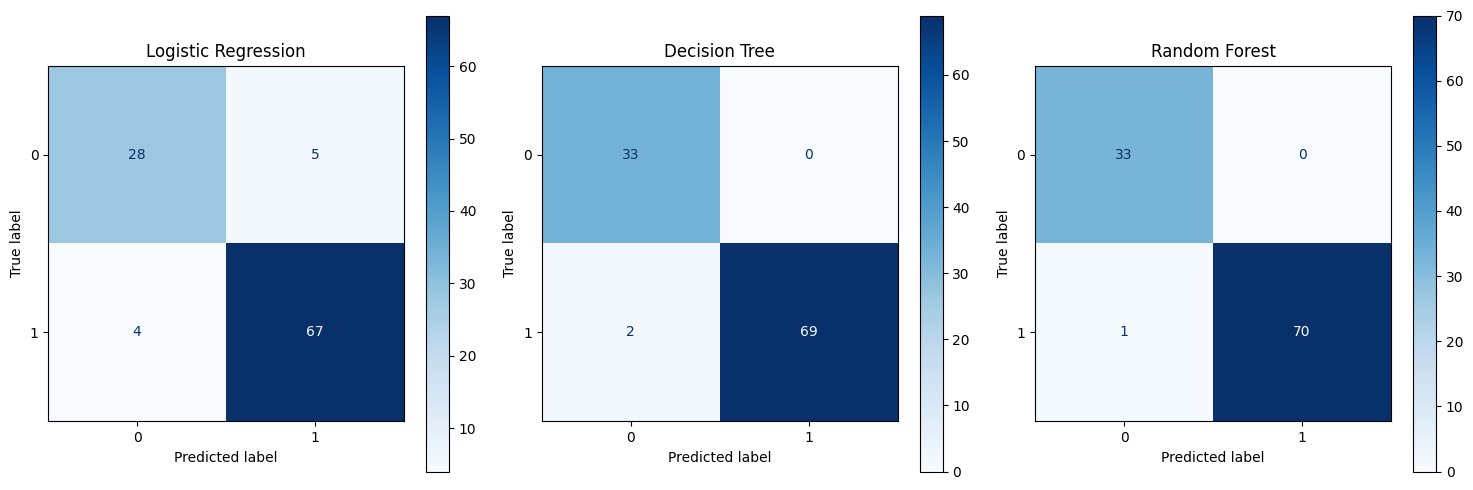

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test, ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, ax=axes[1], cmap="Blues")
axes[1].set_title("Decision Tree")

# Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[2], cmap="Blues")
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

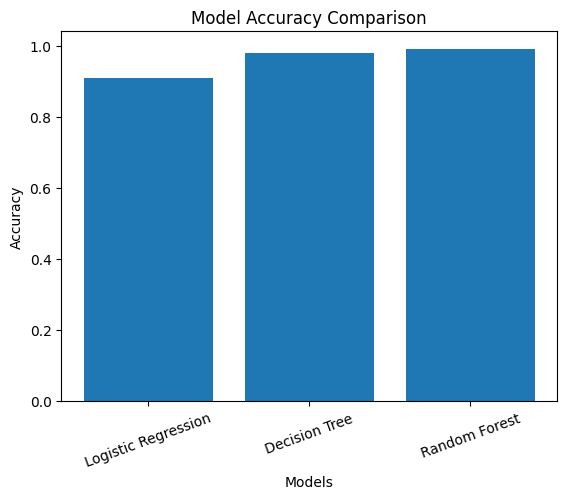

In [43]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.91, 0.98, 0.99]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

The bar chart compares the accuracy of the three models. Logistic Regression shows the lowest accuracy, while Decision Tree performs significantly better. Random Forest achieves the highest accuracy, indicating the best predictive performance among the models. This demonstrates the advantage of ensemble methods in improving model accuracy.

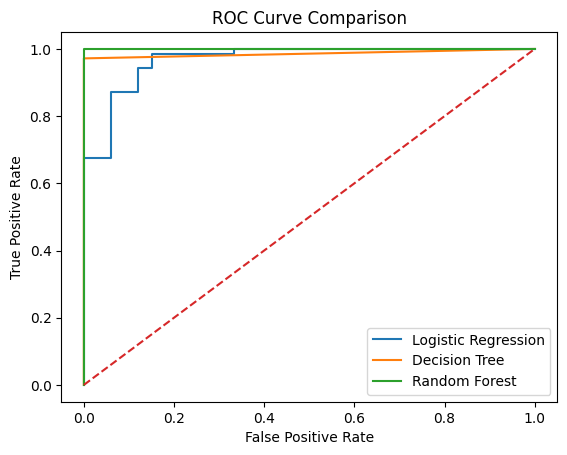

In [44]:
from sklearn.metrics import roc_curve

# Get probabilities
lr_probs = lr.predict_proba(X_test)[:,1]
dt_probs = dt.predict_proba(X_test)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure()
plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

The ROC curve compares the classification performance of all three models. Random Forest shows the best performance with a curve closest to the top-left corner, indicating a higher true positive rate and lower false positive rate. Decision Tree also performs well, while Logistic Regression shows comparatively lower performance. Overall, Random Forest demonstrates the strongest ability to distinguish between classes.

From the confusion matrices, Random Forest shows the least misclassification compared to Logistic Regression and Decision Tree, indicating better predictive performance.

###**Q4.D.Trade-off between Interpretability and Performance**

There is a clear trade-off between interpretability and performance in this problem. Logistic Regression is highly interpretable, as the effect of each feature can be directly understood, but it provides lower predictive performance due to its linear assumptions. Decision Trees offer moderate interpretability, as the decision rules can be visualized, while achieving better performance. Random Forest, although the most accurate, is less interpretable because it combines multiple trees, making the decision process complex. Therefore, while simpler models are easier to explain, more complex models like Random Forest deliver superior predictive results for this dataset.

##**Q5.Robustness, Interpretation & Deployment Thinking**

 ### **Q5.A. Perform feature importance analysis:**
 *   Identify top contributing symptoms




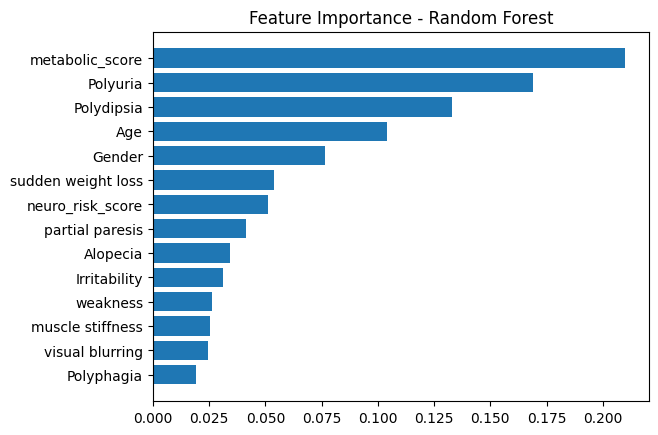

,Feature,Importance
2,metabolic_score,0.209939
0,Polyuria,0.168999
1,Polydipsia,0.133144
11,Age,0.103981
4,Gender,0.076430


In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importances = rf.feature_importances_
features = X.columns

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

# Show top features
feat_df.head(5)

Feature Importance Analysis

The feature importance analysis reveals that metabolic_score is the most influential predictor, followed by Polyuria and Polydipsia, which are key symptoms associated with diabetes. Age and Gender also contribute moderately to the model’s predictions.

Overall, the model prioritizes core clinical symptoms and aggregated risk indicators, indicating that these features play a crucial role in accurate classification.

###**Q5.B Conduct robustness test:**

*   Remove top features and retrain  

*    Observe performance impact  

In [91]:
# Remove top 3 important features
X_reduced = X.drop(["metabolic_score", "Polyuria", "Polydipsia"], axis=1)

# Train-test split again
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

rf_reduced = RandomForestClassifier(random_state=42)
rf_reduced.fit(X_train_r, y_train_r)

y_pred_r = rf_reduced.predict(X_test_r)

print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("\nClassification Report:\n", classification_report(y_test_r, y_pred_r))
print("ROC-AUC:", roc_auc_score(y_test_r, rf_reduced.predict_proba(X_test_r)[:,1]))

Accuracy: 0.9711538461538461

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96        33
           1       0.99      0.97      0.98        71

    accuracy                           0.97       104
   macro avg       0.96      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104

ROC-AUC: 0.9970123772940676


**Robustness Analysis**

After removing the top contributing features (metabolic_score, Polyuria, and Polydipsia), the model's accuracy decreased from approximately 0.99 to 0.97, indicating a slight drop in performance. However, the model still maintains high accuracy and ROC-AUC, suggesting that it is relatively robust and not entirely dependent on a few features.

This indicates that while the removed features are important, other features also contribute meaningfully to the prediction, ensuring stable model performance.

### **Q5.C. Which features are indispensable for prediction?**
**Indispensable Features for Prediction**

Metabolic_score, Polyuria, and Polydipsia are the most crucial features for prediction because their removal causes a discernible decline in model performance. These characteristics are essential for precise classification and are closely linked to the desired result.

The robustness study, however, demonstrates that the model still functions well in their absence, suggesting that additional features, albeit to a lower degree, also influence the prediction.

### **Q5.D. Briefly discuss:**
**Deployment in a Real-World Clinical Screening System**


In a healthcare system, the trained model can be used as a clinical decision-support tool to help with early diabetes screening. A digital interface, such as a hospital management system or mobile application, can be used to gather patient data, including symptoms and basic demographic information. After that, the program may produce predictions in real time to assist medical professionals in identifying people who are at high risk.


The system should include user-friendly interfaces, appropriate data validation, and safe storage of private patient data in order to guarantee dependability. To keep the model accurate over time, it should also be routinely checked and updated with fresh data. Practical adoption also requires respect to medical rules and integration with current clinical operations.